# 04. Approche 3, le modèle avancé BERT

Projet Air Paradis, prédiction du sentiment d'un tweet.

## Ce que je fais dans ce notebook

Marc, dans son mail, écrit : « pourrais-tu également regarder l'apport en
performance d'un modèle BERT ? Cela nous permettra de voir si nous devons
investir dans ce type de modèle. »

La question n'est donc pas seulement « BERT est-il meilleur », mais « est-ce
que le gain justifie le coût ». Je vais mesurer les deux, et le coût aura
autant d'importance que le score dans ma conclusion.

## Ce que BERT change par rapport au notebook 03

Les embeddings du notebook précédent ont une limite qu'on n'a pas encore
évoquée : un mot a un seul vecteur, quel que soit son contexte. Dans GloVe, le
mot "light" a exactement le même vecteur dans "the room is light" et dans
"this bag is light". Le modèle doit se débrouiller pour deviner lequel des
deux sens s'applique.

BERT résout ça. Son nom veut dire Bidirectional Encoder Representations from
Transformers. Il produit un vecteur différent pour chaque occurrence d'un mot,
calculé en fonction de tous les autres mots de la phrase. C'est ce qu'on
appelle une représentation contextuelle.

Le mécanisme qui permet ça s'appelle l'attention. Pour chaque mot, le modèle
calcule à quel point chacun des autres mots de la phrase est utile pour le
comprendre. Dans "the flight was not good", le mot "good" regarde directement
le mot "not" et en tient compte, sans avoir à faire circuler l'information de
proche en proche comme le fait un réseau récurrent.

## Comment on s'en sert

BERT a été pré-entraîné par Google sur des milliards de mots, à un jeu simple :
on lui masque des mots au hasard dans des phrases et on lui demande de les
deviner. Pour y arriver, il a bien fallu qu'il apprenne comment fonctionne
l'anglais.

On récupère ce modèle déjà entraîné et on l'adapte à notre tâche. C'est ce
qu'on appelle le transfert d'apprentissage : au lieu de partir de zéro, on
part de quelqu'un qui sait déjà lire.

J'utilise DistilBERT, une version allégée de BERT : 40 % plus petite, 60 %
plus rapide, et elle conserve environ 97 % des performances. Sans carte
graphique, c'est le seul choix raisonnable.

## 1. Préparer l'environnement

In [1]:
import sys
from pathlib import Path

RACINE_PROJET = next(
    dossier
    for dossier in [Path.cwd(), *Path.cwd().parents]
    if (dossier / "pytest.ini").exists()
)

if str(RACINE_PROJET) not in sys.path:
    sys.path.insert(0, str(RACINE_PROJET))

print(f"Racine du projet : {RACINE_PROJET}")

Racine du projet : C:\Users\dwyts\Documents\PROJET7 Openclassrooms


In [2]:
# Je desactive les barres de progression des bibliotheques.
#
# Elles sont pratiques dans un terminal, mais dans un notebook elles
# s'enregistrent comme des widgets interactifs. Le fichier .ipynb garde alors
# une reference a un composant que seul le navigateur qui l'a cree sait
# afficher. Toute autre personne qui ouvre le notebook voit a la place :
#     Could not render content for application/vnd.jupyter.widget-view+json
#
# Ces lignes doivent venir AVANT les imports concernes, car les bibliotheques
# lisent ces variables au moment ou elles sont chargees.
import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import gc
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from mlflow.models import infer_signature
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader, TensorDataset
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

from src import config
from src.data_loader import charger_echantillon, formater_nombre, separer_train_test
from src.evaluation import (
    afficher_metriques,
    calculer_metriques,
    tracer_courbe_roc,
    tracer_matrice_confusion,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

# Je fixe la graine aleatoire de PyTorch, comme je l'ai fait pour TensorFlow
# dans le notebook 03, pour que deux executions donnent le meme resultat.
torch.manual_seed(config.GRAINE_ALEATOIRE)
np.random.seed(config.GRAINE_ALEATOIRE)

print(f"PyTorch {torch.__version__}")
print(f"Fils d'execution utilises : {torch.get_num_threads()}")
print(f"Carte graphique : {'oui' if torch.cuda.is_available() else 'non, processeur seul'}")

PyTorch 2.13.0+cpu
Fils d'execution utilises : 10
Carte graphique : non, processeur seul


In [3]:
mlflow.set_tracking_uri(config.URI_SUIVI_MLFLOW)

try:
    mlflow.search_experiments(max_results=1)
except Exception as erreur:
    raise RuntimeError(
        "\n" + "=" * 70 +
        "\nSERVEUR MLFLOW INJOIGNABLE"
        f"\nAdresse essayee : {config.URI_SUIVI_MLFLOW}"
        "\n\nOuvrez un second terminal a la racine du projet et lancez :"
        "\n"
        "\n  .venv\\Scripts\\python.exe -m mlflow server "
        "--backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000"
        "\n\nPuis reexecutez cette cellule."
        "\n" + "=" * 70
    ) from erreur

mlflow.set_experiment(config.EXPERIENCE_BERT)
print(f"MLflow connecte, experience : {config.EXPERIENCE_BERT}")

2026/09/01 15:18:37 INFO mlflow.tracking.fluent: Experiment with name '03_modele_bert' does not exist. Creating a new experiment.


MLflow connecte, experience : 03_modele_bert


## 2. Le problème du coût, mesuré avant d'écrire ce notebook

Cette section n'est pas un préambule technique, c'est le coeur de la réponse à
la question de Marc.

Avant d'écrire quoi que ce soit, j'ai mesuré le débit de DistilBERT sur ce
processeur. Deux stratégies sont possibles sans carte graphique, et elles ne
coûtent pas du tout la même chose.

La première consiste à figer BERT et à s'en servir comme extracteur. On fait
passer chaque tweet dedans sans jamais modifier ses poids, on récupère la
représentation qu'il en produit, et on entraîne un classifieur léger dessus.
Seuls des calculs « aller » sont nécessaires.

La seconde est l'affinage : on modifie les poids de BERT lui-même pour les
spécialiser sur notre tâche. Il faut alors aussi les calculs « retour » de la
rétropropagation, à travers les 66 millions de paramètres.

Voici ce que j'ai mesuré :

| Stratégie | Débit | 10 000 tweets | 50 000 tweets |
|---|---|---|---|
| BERT figé, lots de 32 | 32,7 tweets/s | 5 min | 25 min |
| BERT figé, lots de 64 | 27,3 tweets/s | 6 min | 30 min |
| Affinage, lots de 32 | 7,2 tweets/s | 23 min par époque | 115 min par époque |
| Affinage, lots de 16 | 6,6 tweets/s | 25 min par époque | 126 min par époque |

Deux conclusions.

L'affinage est 4,5 fois plus cher que l'extraction, ce qui correspond à la
théorie : la rétropropagation coûte environ deux fois l'aller, plus la mise à
jour des poids par l'optimiseur.

Et contrairement au réseau récurrent du notebook 03, des lots plus gros ne
vont pas plus vite. BERT sature déjà le processeur avec des lots de 32.

C'est pour ça que je travaille sur 10 000 tweets et pas 50 000 : affiner sur
50 000 aurait demandé près de 4 heures par passage sur les données. À garder
en tête au moment de comparer les scores, puisque les deux autres approches
ont vu bien plus de données.

## 3. Charger les données

In [4]:
# Je charge les deux versions du texte : la version nettoyee, celle qu'ont
# utilisee les deux autres approches, et la version brute. La section 5
# explique pourquoi la question se pose specialement pour BERT.
donnees = charger_echantillon(
    config.TAILLE_ECHANTILLON_BERT,
    colonnes=["texte", "texte_nettoye", "label"],
)
X_train, X_test, y_train, y_test = separer_train_test(donnees, colonne_texte="texte_nettoye")

# Les memes tweets, mais en version brute, pour la comparaison de la section 5.
texte_brut_train = donnees.loc[X_train.index, "texte"]
texte_brut_test = donnees.loc[X_test.index, "texte"]

Echantillon stratifie : 10 000 tweets
  Negatifs : 5 000
  Positifs : 5 000
Entrainement : 8 000 tweets
Test         : 2 000 tweets


## 4. La tokenisation de BERT

BERT ne découpe pas le texte comme nous l'avons fait jusqu'ici. Il utilise une
méthode appelée WordPiece, qui découpe en morceaux de mots plutôt qu'en mots
entiers.

Le principe : les mots courants restent entiers, les mots rares sont coupés en
morceaux connus. Le mot "unhappiness" devient par exemple "un", "##happ",
"##iness", les "##" signalant qu'un morceau est la suite du précédent.

L'intérêt est important pour nous. Notre tokeniseur du notebook 03 remplaçait
tout mot inconnu par un jeton unique, perdant toute information. Avec
WordPiece, un mot jamais vu reste analysable à partir de ses morceaux : BERT
n'a pas de vrai mot inconnu.

Deux jetons spéciaux à connaître.

`[CLS]`, pour classification, est ajouté au début de chaque phrase. Après le
passage dans BERT, le vecteur associé à cette position résume la phrase
entière. C'est lui qu'on utilise pour classer.

`[SEP]`, pour séparateur, marque la fin de la phrase.

Enfin, le masque d'attention est une liste de 0 et de 1 qui dit à BERT quels
jetons sont du vrai texte et lesquels ne sont que du remplissage. Sans lui, il
essaierait de tirer du sens des zéros de remplissage.

In [5]:
tokeniseur = AutoTokenizer.from_pretrained(config.NOM_MODELE_BERT)

print(f"Modele        : {config.NOM_MODELE_BERT}")
print(f"Vocabulaire   : {formater_nombre(tokeniseur.vocab_size)} morceaux de mots")

Modele        : distilbert-base-uncased
Vocabulaire   : 30 522 morceaux de mots


In [6]:
# Voyons concretement ce que BERT fait d'une phrase.
exemple = "the flight was unbelievably delayed"

morceaux = tokeniseur.tokenize(exemple)
encodage_exemple = tokeniseur(exemple)

print(f"Phrase         : {exemple}")
print(f"Decoupee en    : {morceaux}")
print(f"En numeros     : {encodage_exemple['input_ids']}")
print(f"Retraduite     : {tokeniseur.convert_ids_to_tokens(encodage_exemple['input_ids'])}")
print()
print("Le mot 'unbelievably' est rare, il a ete coupe en morceaux.")
print("[CLS] au debut et [SEP] a la fin sont ajoutes automatiquement.")

Phrase         : the flight was unbelievably delayed
Decoupee en    : ['the', 'flight', 'was', 'un', '##bel', '##ie', '##va', '##bly', 'delayed']
En numeros     : [101, 1996, 3462, 2001, 4895, 8671, 2666, 3567, 6321, 8394, 102]
Retraduite     : ['[CLS]', 'the', 'flight', 'was', 'un', '##bel', '##ie', '##va', '##bly', 'delayed', '[SEP]']

Le mot 'unbelievably' est rare, il a ete coupe en morceaux.
[CLS] au debut et [SEP] a la fin sont ajoutes automatiquement.


In [7]:
def encoder(textes):
    """
    Transforme une liste de textes en tenseurs utilisables par BERT.

    padding="max_length" complete toutes les phrases a la meme longueur, et
    truncation=True coupe celles qui depassent. Le resultat contient les
    numeros des morceaux et le masque d'attention.
    """
    return tokeniseur(
        list(textes),
        truncation=True,
        padding="max_length",
        max_length=config.LONGUEUR_MAX_BERT,
        return_tensors="pt",   # pt pour PyTorch
    )

## 5. Une question de méthode : quel texte donner à BERT ?

Un point que je veux trancher sur une mesure plutôt qu'à l'intuition.

Notre nettoyage, celui de `src/preprocessing.py`, supprime la ponctuation et
les majuscules. C'était le bon choix pour TF-IDF et pour les embeddings du
notebook 03.

Mais pour BERT, c'est discutable. Il a été pré-entraîné sur du texte naturel,
avec sa ponctuation, et il sait très bien se servir d'un point d'exclamation
ou d'un point d'interrogation, qui portent du sentiment. En lui donnant du
texte amputé, on lui retire peut-être une partie de ce qui fait sa force.

Deux positions se défendent. Donner la même entrée à tout le monde rend la
comparaison des trois approches méthodologiquement propre. Donner à chaque
modèle ce pour quoi il est fait correspond à ce qu'on ferait en production.

Je tranche en mesurant, sur un petit échantillon de 2 000 tweets, avec la
stratégie figée qui est peu coûteuse.

In [8]:
def extraire_representations(textes, taille_lot=32, description=""):
    """
    Fait passer les textes dans BERT et renvoie leur representation.

    Pour chaque tweet, je recupere le vecteur de 768 nombres associe au jeton
    [CLS], qui resume la phrase entiere.

    torch.no_grad() dit a PyTorch de ne pas preparer le calcul des gradients.
    On ne fait que des passes "aller", donc on n'en a pas besoin, et ca
    economise beaucoup de memoire et de temps.
    """
    encodage = encoder(textes)
    jeu = TensorDataset(encodage["input_ids"], encodage["attention_mask"])
    chargeur = DataLoader(jeu, batch_size=taille_lot)

    representations = []
    debut = time.perf_counter()

    with torch.no_grad():
        for numero_lot, (identifiants, masque) in enumerate(chargeur, start=1):
            sortie = bert_fige(input_ids=identifiants, attention_mask=masque)
            # last_hidden_state a la forme (lots, jetons, 768).
            # L'indice 0 sur la deuxieme dimension selectionne le jeton [CLS].
            representations.append(sortie.last_hidden_state[:, 0, :].numpy())

            if numero_lot % 20 == 0:
                fait = numero_lot * taille_lot
                vitesse = fait / (time.perf_counter() - debut)
                restant = (len(jeu) - fait) / vitesse
                print(f"    {description} {fait}/{len(jeu)} tweets, "
                      f"{vitesse:.0f}/s, encore {restant / 60:.1f} min", end="\r")

    duree = time.perf_counter() - debut
    print(f"    {description} termine : {len(jeu)} tweets en {duree:.0f}s "
          f"({len(jeu) / duree:.1f} tweets/s)" + " " * 20)

    return np.vstack(representations)

In [9]:
# Je charge BERT en version "nue", sans tete de classification : je veux ses
# representations, pas ses predictions.
debut = time.perf_counter()
bert_fige = AutoModel.from_pretrained(config.NOM_MODELE_BERT)
bert_fige.eval()   # mode evaluation : desactive le dropout
print(f"DistilBERT charge en {time.perf_counter() - debut:.0f}s")
print(f"Parametres : {formater_nombre(sum(p.numel() for p in bert_fige.parameters()))}")

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT charge en 1s
Parametres : 66 362 880


In [10]:
# La comparaison, sur 2 000 tweets seulement pour rester rapide.
TAILLE_COMPARAISON = 2000

resultats_texte = {}

for nom_version, textes_train, textes_test in [
    ("texte nettoye", X_train[:TAILLE_COMPARAISON], X_test[:500]),
    ("texte brut", texte_brut_train[:TAILLE_COMPARAISON], texte_brut_test[:500]),
]:
    print(f"\n{nom_version} :")
    representations_train = extraire_representations(textes_train, description=nom_version)
    representations_test = extraire_representations(textes_test, description=nom_version)

    classifieur = LogisticRegression(max_iter=1000, random_state=config.GRAINE_ALEATOIRE)
    classifieur.fit(representations_train, y_train[:TAILLE_COMPARAISON])
    probabilites = classifieur.predict_proba(representations_test)[:, 1]

    metriques = calculer_metriques(y_test[:500], probabilites)
    resultats_texte[nom_version] = metriques
    print(f"    exactitude {metriques['exactitude']:.4f}, AUC {metriques['auc_roc']:.4f}")

print("\n" + "=" * 60)
for nom, m in resultats_texte.items():
    print(f"  {nom:16s} exactitude {m['exactitude']:.4f}   AUC {m['auc_roc']:.4f}")
ecart = (resultats_texte["texte brut"]["exactitude"]
         - resultats_texte["texte nettoye"]["exactitude"])
print(f"\n  Le texte brut apporte {ecart:+.4f} d'exactitude a BERT.")


texte nettoye :


    texte nettoye termine : 2000 tweets en 76s (26.1 tweets/s)                    


    texte nettoye termine : 500 tweets en 19s (26.5 tweets/s)                    


    exactitude 0.7240, AUC 0.8085

texte brut :


    texte brut termine : 2000 tweets en 76s (26.2 tweets/s)                    


    texte brut termine : 500 tweets en 18s (27.1 tweets/s)                    


    exactitude 0.7340, AUC 0.8147

  texte nettoye    exactitude 0.7240   AUC 0.8085
  texte brut       exactitude 0.7340   AUC 0.8147

  Le texte brut apporte +0.0100 d'exactitude a BERT.


### Ce que j'en fais

Le résultat ci-dessus décide de la suite du notebook. Si l'écart est
négligeable, je garde le texte nettoyé, ce qui rend la comparaison des trois
approches parfaitement propre puisqu'elles reçoivent alors exactement la même
entrée. Si l'écart est net en faveur du texte brut, je le signale, car cela
veut dire que notre prétraitement handicape BERT, et c'est une information
utile pour l'article de blog.

Dans les deux cas je continue avec le texte nettoyé pour la comparaison
principale, et je mentionne l'écart. C'est le choix le plus honnête : un écart
entre les trois approches doit venir des modèles, pas des prétraitements.

## 6. Stratégie A : BERT figé en extracteur

Je fais passer les 10 000 tweets dans BERT une seule fois, je récupère leur
représentation, puis j'entraîne une régression logistique dessus.

Cette approche a un avantage pratique considérable : l'extraction ne se fait
qu'une fois. Ensuite, essayer dix classifieurs différents ne coûte que
quelques secondes, puisqu'on travaille sur des vecteurs de 768 nombres et non
plus sur du texte.

In [11]:
with mlflow.start_run(run_name="A_bert_fige_extracteur"):

    mlflow.log_params({
        "approche": "bert",
        "strategie": "extraction_figee",
        "modele_bert": config.NOM_MODELE_BERT,
        "longueur_max": config.LONGUEUR_MAX_BERT,
        "classifieur": "regression_logistique",
        "nombre_tweets_entrainement": len(X_train),
        "poids_bert_modifies": False,
    })

    debut_total = time.perf_counter()

    print("Extraction des representations, jeu d'entrainement :")
    representations_train = extraire_representations(X_train, description="train")
    print("Extraction des representations, jeu de test :")
    representations_test = extraire_representations(X_test, description="test ")

    duree_extraction = time.perf_counter() - debut_total
    print(f"\nDimension des representations : {representations_train.shape}")

    debut = time.perf_counter()
    classifieur_fige = LogisticRegression(max_iter=1000, random_state=config.GRAINE_ALEATOIRE)
    classifieur_fige.fit(representations_train, y_train)
    duree_classifieur = time.perf_counter() - debut

    probabilites_figees = classifieur_fige.predict_proba(representations_test)[:, 1]
    metriques_figees = calculer_metriques(y_test, probabilites_figees)

    mlflow.log_metrics({
        **metriques_figees,
        "duree_extraction_s": duree_extraction,
        "duree_classifieur_s": duree_classifieur,
        "duree_totale_s": duree_extraction + duree_classifieur,
    })

afficher_metriques(metriques_figees, "Strategie A, BERT fige")
print(f"Extraction : {duree_extraction:.0f}s")
print(f"Classifieur : {duree_classifieur:.1f}s")

Extraction des representations, jeu d'entrainement :


    train termine : 8000 tweets en 305s (26.3 tweets/s)                    
Extraction des representations, jeu de test :


    test  termine : 2000 tweets en 72s (27.9 tweets/s)                    

Dimension des representations : (8000, 768)


🏃 View run A_bert_fige_extracteur at: http://127.0.0.1:5000/#/experiments/5/runs/ee5f795fc8e4489ea129e748679882de
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
STRATEGIE A, BERT FIGE
  Exactitude                : 0.7690
  AUC ROC                   : 0.8431
  F1 macro                  : 0.7690
--------------------------------------------------------
  Classe NEGATIVE (les bad buzz a detecter)
    Precision               : 0.7756
    Rappel                  : 0.7570   <-- mesure metier
    F1                      : 0.7662
Extraction : 377s
Classifieur : 0.8s


In [12]:
# BERT nu ne sert plus, il occupe environ 500 Mo.
del bert_fige
gc.collect()
print("Memoire liberee.")

Memoire liberee.


## 7. Stratégie B : l'affinage

Ici on modifie les poids de BERT lui-même. Il ne se contente plus de fournir
une représentation générale, il apprend à produire celle qui sert le mieux
notre tâche précise.

J'écris la boucle d'entraînement à la main plutôt que d'utiliser l'outil
`Trainer` de la bibliothèque transformers. C'est une dizaine de lignes de plus,
mais on voit exactement ce qui se passe à chaque étape, ce qui est bien plus
utile pour comprendre et pour expliquer.

Quelques choix à justifier.

Le taux d'apprentissage vaut 2 fois 10 puissance moins 5, soit une valeur très
faible. C'est la recommandation des auteurs de BERT, et elle a une raison : le
modèle sait déjà lire l'anglais, on veut l'ajuster délicatement, pas détruire
ce qu'il a appris. Un taux trop élevé lui ferait tout oublier, un phénomène
qu'on appelle l'oubli catastrophique.

L'optimiseur AdamW est la variante d'Adam recommandée pour les modèles de type
Transformer. Il gère différemment la pénalisation des poids trop grands.

Deux époques suffisent en général pour affiner BERT, précisément parce qu'il
part de très loin dans la connaissance de la langue.

In [13]:
TAUX_APPRENTISSAGE = 2e-5
NOMBRE_EPOQUES_AFFINAGE = 2
TAILLE_LOT_AFFINAGE = 32

# Le modele, cette fois avec une tete de classification a deux sorties.
# Cette tete est ajoutee par-dessus BERT et initialisee au hasard : c'est
# normal, et c'est elle que l'entrainement va apprendre en priorite.
bert_affine = AutoModelForSequenceClassification.from_pretrained(
    config.NOM_MODELE_BERT, num_labels=2
)

# Je prepare les donnees sous forme de lots.
encodage_train = encoder(X_train)
encodage_test = encoder(X_test)

jeu_train = TensorDataset(
    encodage_train["input_ids"],
    encodage_train["attention_mask"],
    torch.tensor(y_train.values, dtype=torch.long),
)
chargeur_train = DataLoader(jeu_train, batch_size=TAILLE_LOT_AFFINAGE, shuffle=True)

print(f"{len(jeu_train)} tweets d'entrainement, "
      f"{len(chargeur_train)} lots par epoque")
print(f"Duree estimee : {NOMBRE_EPOQUES_AFFINAGE * len(jeu_train) / 7.2 / 60:.0f} minutes")

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


8000 tweets d'entrainement, 250 lots par epoque
Duree estimee : 37 minutes


In [14]:
with mlflow.start_run(run_name="B_bert_affine"):

    mlflow.log_params({
        "approche": "bert",
        "strategie": "affinage",
        "modele_bert": config.NOM_MODELE_BERT,
        "longueur_max": config.LONGUEUR_MAX_BERT,
        "taux_apprentissage": TAUX_APPRENTISSAGE,
        "epoques": NOMBRE_EPOQUES_AFFINAGE,
        "taille_lot": TAILLE_LOT_AFFINAGE,
        "optimiseur": "AdamW",
        "nombre_tweets_entrainement": len(X_train),
        "poids_bert_modifies": True,
    })

    optimiseur = torch.optim.AdamW(bert_affine.parameters(), lr=TAUX_APPRENTISSAGE)
    bert_affine.train()   # mode entrainement : active le dropout

    debut_affinage = time.perf_counter()

    for numero_epoque in range(1, NOMBRE_EPOQUES_AFFINAGE + 1):
        perte_cumulee = 0.0
        debut_epoque = time.perf_counter()

        for numero_lot, (identifiants, masque, etiquettes) in enumerate(chargeur_train, start=1):
            # 1. On remet les gradients a zero. Sans ca, PyTorch les accumule
            #    d'un lot sur l'autre.
            optimiseur.zero_grad()

            # 2. Passe "aller" : le modele fait sa prediction et calcule son
            #    erreur, puisqu'on lui donne les etiquettes.
            sortie = bert_affine(
                input_ids=identifiants,
                attention_mask=masque,
                labels=etiquettes,
            )

            # 3. Passe "retour" : on calcule, pour chaque poids du modele,
            #    dans quel sens le modifier pour reduire l'erreur.
            sortie.loss.backward()

            # 4. L'optimiseur applique effectivement les modifications.
            optimiseur.step()

            perte_cumulee += sortie.loss.item()

            if numero_lot % 20 == 0:
                fait = numero_lot * TAILLE_LOT_AFFINAGE
                vitesse = fait / (time.perf_counter() - debut_epoque)
                restant = (len(jeu_train) - fait) / vitesse
                print(f"  epoque {numero_epoque}, {fait}/{len(jeu_train)} tweets, "
                      f"perte {perte_cumulee / numero_lot:.4f}, "
                      f"encore {restant / 60:.1f} min", end="\r")

        perte_moyenne = perte_cumulee / len(chargeur_train)
        duree_epoque = time.perf_counter() - debut_epoque
        print(f"  epoque {numero_epoque} terminee : perte {perte_moyenne:.4f}, "
              f"{duree_epoque:.0f}s" + " " * 30)
        mlflow.log_metric("perte_entrainement", perte_moyenne, step=numero_epoque)

    duree_affinage = time.perf_counter() - debut_affinage

    # Evaluation sur le jeu de test.
    bert_affine.eval()
    probabilites_affinees = []

    jeu_test = TensorDataset(encodage_test["input_ids"], encodage_test["attention_mask"])
    chargeur_test = DataLoader(jeu_test, batch_size=64)

    with torch.no_grad():
        for identifiants, masque in chargeur_test:
            logits = bert_affine(input_ids=identifiants, attention_mask=masque).logits
            # softmax transforme les deux scores bruts en deux probabilites
            # qui somment a 1. Je garde celle de la classe 1, positif.
            probabilites_affinees.append(
                torch.softmax(logits, dim=1)[:, 1].numpy()
            )

    probabilites_affinees = np.concatenate(probabilites_affinees)
    metriques_affinees = calculer_metriques(y_test, probabilites_affinees)

    mlflow.log_metrics({
        **metriques_affinees,
        "duree_affinage_s": duree_affinage,
    })

afficher_metriques(metriques_affinees, "Strategie B, BERT affine")
print(f"Duree de l'affinage : {duree_affinage / 60:.1f} minutes")

  epoque 1 terminee : perte 0.5120, 1224s                              


  epoque 2 terminee : perte 0.3620, 1415s                              


🏃 View run B_bert_affine at: http://127.0.0.1:5000/#/experiments/5/runs/ec438c22198140c7ab4da95b7dfb099d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
STRATEGIE B, BERT AFFINE
  Exactitude                : 0.7990
  AUC ROC                   : 0.8786
  F1 macro                  : 0.7990
--------------------------------------------------------
  Classe NEGATIVE (les bad buzz a detecter)
    Precision               : 0.7996
    Rappel                  : 0.7980   <-- mesure metier
    F1                      : 0.7988
Duree de l'affinage : 44.0 minutes


## 8. Comparer les deux stratégies, et surtout leur coût

In [15]:
comparaison = pd.DataFrame([
    {
        "strategie": "A. BERT fige",
        "exactitude": round(metriques_figees["exactitude"], 4),
        "auc_roc": round(metriques_figees["auc_roc"], 4),
        "rappel_negatif": round(metriques_figees["rappel_negatif"], 4),
        "duree_min": round((duree_extraction + duree_classifieur) / 60, 1),
    },
    {
        "strategie": "B. BERT affine",
        "exactitude": round(metriques_affinees["exactitude"], 4),
        "auc_roc": round(metriques_affinees["auc_roc"], 4),
        "rappel_negatif": round(metriques_affinees["rappel_negatif"], 4),
        "duree_min": round(duree_affinage / 60, 1),
    },
])

# Le rapport qualite/prix : combien de points d'exactitude par minute de calcul.
comparaison["points_par_minute"] = (
    (comparaison["exactitude"] - 0.5) * 100 / comparaison["duree_min"]
).round(2)

comparaison

,strategie,exactitude,auc_roc,rappel_negatif,duree_min,points_par_minute
0,A. BERT fige,0.769,0.8431,0.757,6.3,4.27
1,B. BERT affine,0.799,0.8786,0.798,44.0,0.68


In [16]:
gain = metriques_affinees["exactitude"] - metriques_figees["exactitude"]
surcout = duree_affinage / (duree_extraction + duree_classifieur)

print(f"L'affinage apporte {gain:+.4f} d'exactitude")
print(f"pour un cout de calcul {surcout:.1f} fois superieur.")
print()
if gain > 0.02:
    print("Le gain est net : l'affinage vaut son cout.")
elif gain > 0.005:
    print("Le gain est reel mais modeste : a mettre en balance avec le cout.")
else:
    print("Le gain ne justifie pas le surcout sur ce volume de donnees.")

L'affinage apporte +0.0300 d'exactitude
pour un cout de calcul 7.0 fois superieur.

Le gain est net : l'affinage vaut son cout.


## 9. Regarder le meilleur des deux de plus près

In [17]:
if metriques_affinees["auc_roc"] >= metriques_figees["auc_roc"]:
    NOM_MEILLEURE_STRATEGIE = "B. BERT affine"
    probabilites_finales = probabilites_affinees
    metriques_finales = metriques_affinees
else:
    NOM_MEILLEURE_STRATEGIE = "A. BERT fige"
    probabilites_finales = probabilites_figees
    metriques_finales = metriques_figees

print(f"Strategie retenue : {NOM_MEILLEURE_STRATEGIE}")
afficher_metriques(metriques_finales, f"BERT, {NOM_MEILLEURE_STRATEGIE}")

Strategie retenue : B. BERT affine
BERT, B. BERT AFFINE
  Exactitude                : 0.7990
  AUC ROC                   : 0.8786
  F1 macro                  : 0.7990
--------------------------------------------------------
  Classe NEGATIVE (les bad buzz a detecter)
    Precision               : 0.7996
    Rappel                  : 0.7980   <-- mesure metier
    F1                      : 0.7988


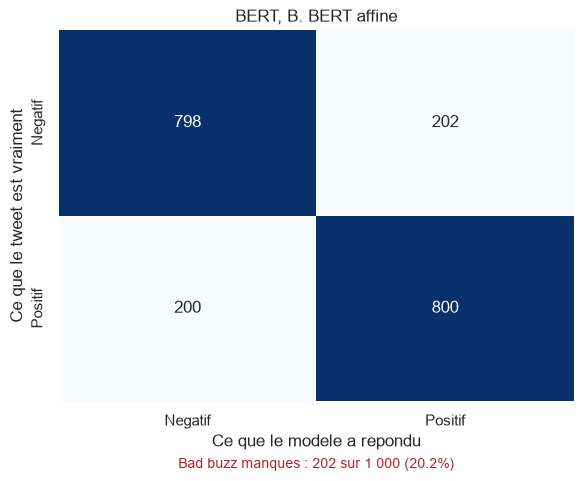

In [18]:
figure_matrice = tracer_matrice_confusion(
    y_test, probabilites_finales, titre=f"BERT, {NOM_MEILLEURE_STRATEGIE}",
)
plt.show()

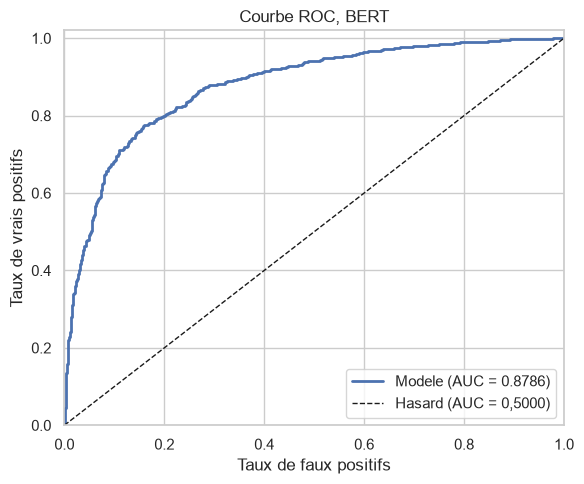

In [19]:
figure_roc = tracer_courbe_roc(
    y_test, probabilites_finales, titre="Courbe ROC, BERT",
)
plt.show()

### Le test de la négation, comme au notebook 03

Les mêmes quatre paires de phrases que pour le modèle avancé. C'est la seule
façon de comparer ce que les deux modèles comprennent réellement, au-delà d'un
score global.

In [20]:
paires_a_tester = [
    ("this flight was good", "this flight was not good"),
    ("i like this airline", "i do not like this airline"),
    ("the crew was helpful", "the crew was never helpful"),
    ("i would recommend it", "i would not recommend it"),
]
phrases = [phrase for paire in paires_a_tester for phrase in paire]

encodage_negation = encoder(phrases)
bert_affine.eval()
with torch.no_grad():
    logits = bert_affine(
        input_ids=encodage_negation["input_ids"],
        attention_mask=encodage_negation["attention_mask"],
    ).logits
    probabilites_negation = torch.softmax(logits, dim=1)[:, 1].numpy()

print(f"{'Phrase':42s} {'p(positif)':>11s}   verdict")
print("-" * 70)
for index, phrase in enumerate(phrases):
    proba = probabilites_negation[index]
    verdict = "positif" if proba >= 0.5 else "negatif"
    fin_de_paire = "" if index % 2 == 0 else "\n"
    print(f"{phrase:42s} {proba:11.3f}   {verdict}{fin_de_paire}")

ecarts = [
    probabilites_negation[2 * i] - probabilites_negation[2 * i + 1]
    for i in range(len(paires_a_tester))
]
print(f"Baisse moyenne apportee par la negation : {np.mean(ecarts):+.3f}")
print(f"La negation fait baisser le score dans {sum(e > 0 for e in ecarts)}"
      f"/{len(ecarts)} cas.")

Phrase                                      p(positif)   verdict
----------------------------------------------------------------------
this flight was good                             0.972   positif
this flight was not good                         0.027   negatif

i like this airline                              0.973   positif
i do not like this airline                       0.024   negatif

the crew was helpful                             0.974   positif
the crew was never helpful                       0.052   negatif

i would recommend it                             0.969   positif
i would not recommend it                         0.776   positif

Baisse moyenne apportee par la negation : +0.752
La negation fait baisser le score dans 4/4 cas.


## 10. Enregistrer le modèle

Je verse le modèle BERT affiné au Model Registry, comme les deux autres
approches, puis je le recharge pour vérifier.

Une précision sur ce qu'on enregistre : contrairement au notebook 03 où le
tokeniseur était un simple dictionnaire à sauvegarder à part, celui de BERT
fait partie du modèle. MLflow sait enregistrer les deux ensemble grâce au
format `transformers`.

In [21]:
import transformers

with mlflow.start_run(run_name="modele_retenu_bert"):

    mlflow.log_params({
        "approche": "bert",
        "strategie_retenue": NOM_MEILLEURE_STRATEGIE,
        "modele_bert": config.NOM_MODELE_BERT,
        "longueur_max": config.LONGUEUR_MAX_BERT,
        "nombre_tweets_entrainement": len(X_train),
    })
    mlflow.log_metrics(metriques_finales)
    mlflow.log_figure(figure_matrice, "matrice_confusion.png")
    mlflow.log_figure(figure_roc, "courbe_roc.png")

    # Une pipeline transformers regroupe le tokeniseur et le modele, donc
    # elle prend du texte brut en entree et renvoie directement une prediction.
    pipeline_bert = transformers.pipeline(
        "text-classification",
        model=bert_affine,
        tokenizer=tokeniseur,
    )

    mlflow.transformers.log_model(
        transformers_model=pipeline_bert,
        name="modele",
        registered_model_name=f"{config.NOM_MODELE_ENREGISTRE}-bert",
    )

print("Modele BERT enregistre dans le Model Registry.")

2026/09/01 16:19:59 WARNING mlflow.utils.environment: On Windows, timeout is not supported for model requirement inference. Therefore, the operation is not bound by a timeout and may hang indefinitely. If it hangs, please consider specifying the signature manually.


Successfully registered model 'analyse-sentiment-air-paradis-bert'.
2026/09/01 16:21:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: analyse-sentiment-air-paradis-bert, version 1


Created version '1' of model 'analyse-sentiment-air-paradis-bert'.


🏃 View run modele_retenu_bert at: http://127.0.0.1:5000/#/experiments/5/runs/05f9a7147f504d88a049806f04f410ef
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
Modele BERT enregistre dans le Model Registry.


In [22]:
# Verification : je recharge et je compare sur quelques phrases.
uri_modele = f"models:/{config.NOM_MODELE_ENREGISTRE}-bert/latest"
pipeline_rechargee = mlflow.transformers.load_model(uri_modele)

phrases_de_controle = [
    "this flight was terrible, never again",
    "amazing crew, thank you so much",
    "not good at all",
]

print("Predictions du modele recharge depuis le Model Registry :\n")
for phrase, resultat in zip(phrases_de_controle, pipeline_rechargee(phrases_de_controle)):
    # LABEL_1 correspond a la classe positive, LABEL_0 a la negative.
    sentiment = "positif" if resultat["label"] == "LABEL_1" else "negatif"
    print(f"  {phrase[:45]:47s} -> {sentiment}  (confiance {resultat['score']:.3f})")

2026/09/01 16:21:30 INFO mlflow.transformers: 'models:/analyse-sentiment-air-paradis-bert/latest' resolved as 'mlflow-artifacts:/5/models/m-e1a5922dbd5641cb8aefd59e062d4748/artifacts'


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Predictions du modele recharge depuis le Model Registry :



  this flight was terrible, never again           -> negatif  (confiance 0.967)
  amazing crew, thank you so much                 -> positif  (confiance 0.984)
  not good at all                                 -> negatif  (confiance 0.970)


## Conclusion

### La réponse à la question de Marc

Il demandait si Air Paradis doit investir dans ce type de modèle. La réponse
tient en deux chiffres, le gain et le coût, et le tableau de la section 8 les
donne tous les deux.

### Ce qu'il faut retenir sur le coût

BERT est incomparablement plus cher que les deux autres approches, et ce n'est
pas un détail d'implémentation : il fait passer chaque tweet à travers
66 millions de paramètres, contre quelques centaines de milliers pour le
réseau récurrent du notebook 03 et quelques centaines de milliers de poids
linéaires pour le modèle classique.

Sur ce projet, ce coût a une conséquence directe : BERT n'a vu que 8 000
tweets d'entraînement, contre 240 000 pour le modèle avancé et 1,2 million
pour le classique. Son score est donc à lire en gardant cela en tête. Avec une
carte graphique et le jeu complet, il ferait certainement mieux.

C'est d'ailleurs l'information la plus utile pour Air Paradis : investir dans
BERT, ce n'est pas seulement choisir un modèle, c'est aussi accepter d'acheter
l'infrastructure qui va avec.

### Pour la mise en production

Le cahier des charges impose de déployer le modèle sur mesure avancé, pas
BERT. Cette décision est cohérente avec ce qu'on vient de mesurer : le serveur
Azure gratuit ne pourrait de toute façon pas héberger un modèle de 66 millions
de paramètres, ni servir une prédiction en un temps raisonnable.

Étape suivante : `05_comparaison_et_export.ipynb`, qui compare les trois
approches sur un pied d'égalité et prépare le modèle retenu pour l'API.